[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f133151fb00>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

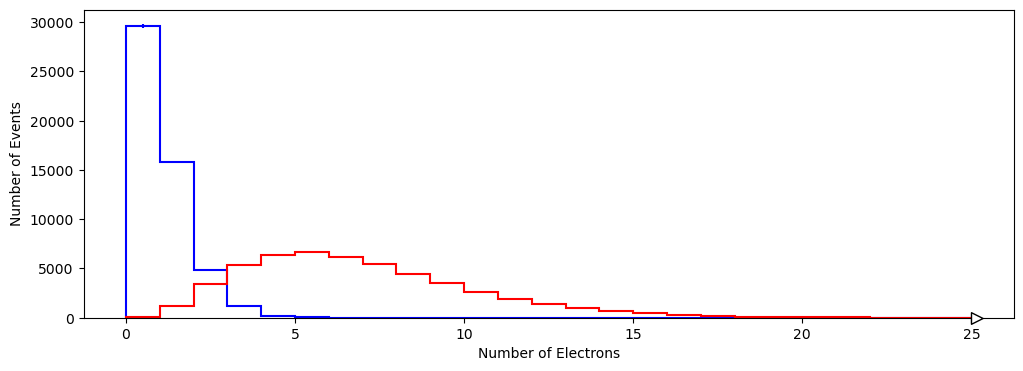

In [3]:
import skhep_testdata
from hist import Hist
import matplotlib.pyplot as plt
import particle
from hepunits import GeV

filename = skhep_testdata.data_path(
    "uproot-Event.root"
)  # downloads this test file and gets a local path to it

file_data = "ffNtuple_2Mu2E_500_0p25_2.root"

import uproot
import numpy as np

file = uproot.open(filename)
file2 = uproot.open(file_data)

t = file2["ffNtuplizer/ffNtuple"]

electron_n = t["electron_n"]
muon_n = t["muon_n"]

h1 = Hist.new.Reg(25, 0, 25, name="electron", label="Number of Electrons").Double()
h1.fill(electron_n)

h2 = Hist.new.Reg(25, 0, 25, name="muon", label="Number of Muons").Double()
h2.fill(muon_n)

# --- Plotting them separately ---
fig, ax = plt.subplots(1, 1, figsize=(12, 4)) # Create a layout with 1 row, 2 columns
#adds y-axis labels
ax.set_ylabel("Number of Events")


h1.plot(ax=ax, color="blue")
h2.plot(ax=ax, color="red")

In [2]:
import skhep_testdata, uproot
import awkward as ak
import vector

tree = uproot.open(skhep_testdata.data_path("uproot-Zmumu.root"))["events"]

one = ak.to_numpy(tree.arrays(filter_name=["E1", "p[xyz]1"]))
two = ak.to_numpy(tree.arrays(filter_name=["E2", "p[xyz]2"]))

one.dtype.names = ("E", "px", "py", "pz")
two.dtype.names = ("E", "px", "py", "pz")

one = one.view(vector.MomentumNumpy4D)
two = two.view(vector.MomentumNumpy4D)

one.deltaR(two)

array([3.10530402, 3.10550819, 3.10547199, ..., 2.81363587, 2.81359933,
       2.81354694], shape=(2304,))

In [23]:
import particle
from hepunits import GeV

electron = particle.Particle.from_name("e-")
electron.mass / GeV, electron.width / GeV

print(electron.describe())

Name: e-             ID: 11           Latex: $e^{-}$
Mass  = 0.51099895000 ± 0.00000000015 MeV
Width = 0.0 MeV
Q (charge)        = -       J (total angular) = 0.5      P (space parity) = None
C (charge parity) = None    I (isospin)       = None     G (G-parity)     = None
    SpinType: 5
    Antiparticle name: e+ (antiparticle status: ChargeInv)


In [7]:
import skhep_testdata, uproot
import awkward as ak
import particle
from hepunits import GeV
import vector

vector.register_awkward()

picodst = uproot.open(
    "https://pivarski-princeton.s3.amazonaws.com/pythia_ppZee_run17emb.picoDst.root:PicoDst"
)
px, py, pz = ak.unzip(
    picodst.arrays(filter_name=["Track/Track.mPMomentum[XYZ]"], entry_stop=100)
)

probable_mass = particle.Particle.from_name("pi+").mass / GeV

pseudojets = ak.zip(
    {"px": px, "py": py, "pz": pz, "mass": probable_mass}, with_name="Momentum4D"
)
good_pseudojets = pseudojets[pseudojets.pt > 0.1]

import fastjet

jetdef = fastjet.JetDefinition(fastjet.antikt_algorithm, 1.0)

clusterseq = fastjet.ClusterSequence(good_pseudojets, jetdef)
clusterseq.inclusive_jets()

ak.num(good_pseudojets), ak.num(clusterseq.inclusive_jets())

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


(<Array [24, 19, 13, 36, 39, 48, ..., 57, 41, 35, 34, 20, 93] type='100 * int64'>,
 <Array [8, 6, 6, 7, 8, 9, 8, 7, ..., 9, 8, 7, 6, 7, 4, 11] type='100 * int64'>)

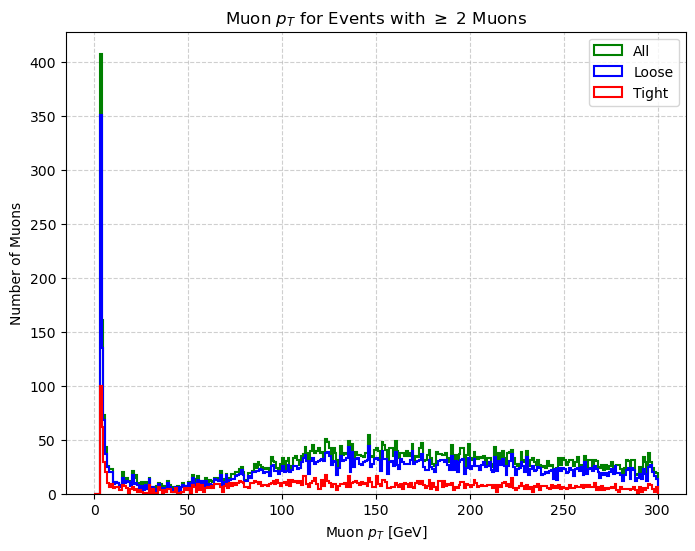

In [8]:
file_data = 'nano_1000_0p25_0p002.root'

import uproot
import numpy as np
import skhep_testdata, uproot
import awkward as ak
import particle
from hepunits import GeV
import vector
import matplotlib.pyplot as plt

file = uproot.open(file_data)


tree = file['Events']

muon_pt = tree["Muon_pt"].array()


muon_looseId = tree['Muon_looseId'].array()

#Needs two or more trues in muon_looseId
two_event_looseId = ak.sum(muon_looseId, axis=1) >= 2

#momenta of muons that pass the loose and event cut
loose_muon_pt = muon_pt[two_event_looseId]


muon_tightId = tree['Muon_tightId'].array()

#Needs two or more trues in muon_tightId
two_event_tightId = ak.sum(muon_tightId, axis=1) >= 2

#momenta of muons that pass the tight and event cut
tight_muon_pt = muon_pt[two_event_tightId]

#print(*ak.flatten(tight_muon_pt))
# 3. Create the plot
plt.figure(figsize=(8, 6))
plt.hist(ak.flatten(muon_pt), bins=300, range=(0, 300), histtype='step', color='green', linewidth=1.5, label="All")
plt.hist(ak.flatten(loose_muon_pt), bins=300, range=(0, 300), histtype='step', color='blue', linewidth=1.5, label="Loose")
plt.hist(ak.flatten(tight_muon_pt), bins=300, range=(0, 300), histtype='step', color='red', linewidth=1.5, label="Tight")


plt.title(r'Muon $p_T$ for Events with $\geq$ 2 Muons')
plt.xlabel(r'Muon $p_T$ [GeV]')
plt.ylabel('Number of Muons')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


In [90]:
import numpy as np

data = np.array([10, 20, 30, 40, 50])
indices = np.array([True, True, False, True, False])
result = data[indices]
print(result)

[10 20 40]


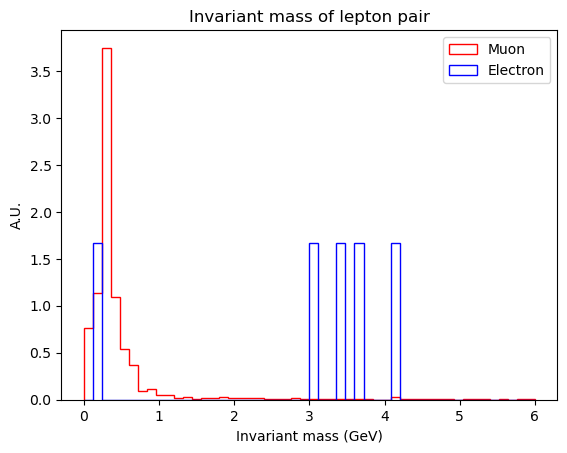

In [18]:
import uproot
import numpy as np
import skhep_testdata, uproot
import awkward as ak
import particle
from hepunits import GeV
import vector
import matplotlib.pyplot as plt

file_names = ["nano_1000_0p25_0p002.root"]


branches_dict = {}

for file_name in file_names:
    temp_file = uproot.open(file_name)
    tree = temp_file['Events']
    #Load all the branches into memory and store in branches_dict (this is slow, and could be done in a 
    #"lazy" way to only read the arrays that we end up using, but I'm too lazy to be lazy)
    branches_dict[file_name] = tree.arrays()
branches = branches_dict[file_names[0]] #store the data from the last file into the branches variable



muon = vector.zip({"pt": branches['Muon_pt'],
                      "eta": branches['Muon_eta'],
                      "phi": branches['Muon_phi'],
                      "mass": branches['Muon_mass'],
                      "looseId": branches['Muon_looseId']})

electron_p4 = vector.zip({"pt": branches['Electron_pt'],
                      "eta": branches['Electron_eta'],
                      "phi": branches['Electron_phi'],
                      "mass": branches['Electron_mass']})

#Apply quality cuts to muons (could add more here)
good_muon_mask = (muon.pt > 100) & (muon.looseId == True) #muon level mask

#Apply the mask
good_muons = muon[good_muon_mask]

#Select events with at least two good muons
two_muons_mask = ak.count(good_muons.pt,1) >= 2 #event level mask
two_muons_p4 = good_muons[two_muons_mask]

first_muon_p4 = two_muons_p4[:, 0]
second_muon_p4 = two_muons_p4[:, 1]
muon_sum_p4 = first_muon_p4 + second_muon_p4 #event level quantity

two_electrons_mask = ak.count(electron_p4.pt,1) >= 2 #event level mask
two_electrons_p4 = electron_p4[two_electrons_mask]
first_electron_p4 = two_electrons_p4[:, 0]
second_electron_p4 = two_electrons_p4[:, 1]
electron_sum_p4 = first_electron_p4 + second_electron_p4 #event level quantity


plt.hist(muon_sum_p4.mass, bins=50, range=(0, 6), color='red', label = "Muon", histtype='step',density=True)
plt.hist(electron_sum_p4.mass, bins=50, range=(0, 6), color='blue', label = "Electron", histtype='step',density=True)


plt.xlabel('Invariant mass (GeV)')
plt.ylabel('A.U.')
plt.title('Invariant mass of lepton pair')
plt.legend(loc = 'upper right')

In [129]:
#Explore the branches in the files
tree.keys(filter_name="GenPart*")

['GenPart_eta',
 'GenPart_mass',
 'GenPart_phi',
 'GenPart_pt',
 'GenPart_genPartIdxMother',
 'GenPart_pdgId',
 'GenPart_status',
 'GenPart_statusFlags',
 'GenPart_vx',
 'GenPart_vy',
 'GenPart_vz',
 'GenPart_px',
 'GenPart_py',
 'GenPart_pz']

In [19]:
muon = vector.zip({"pt": branches['Muon_pt'],
                      "eta": branches['Muon_eta'],
                      "phi": branches['Muon_phi'],
                      "mass": branches['Muon_mass'],
                      "looseId": branches['Muon_looseId']})

electron_p4 = vector.zip({"pt": branches['Electron_pt'],
                      "eta": branches['Electron_eta'],
                      "phi": branches['Electron_phi'],
                      "mass": branches['Electron_mass']})

gen = vector.zip({"pt": branches['GenPart_pt'],
                      "eta": branches['GenPart_eta'],
                      "phi": branches['GenPart_phi'],
                      "mass": branches['GenPart_mass'],
                       "id": branches['GenPart_pdgId'],
                       "status": branches['GenPart_status']})

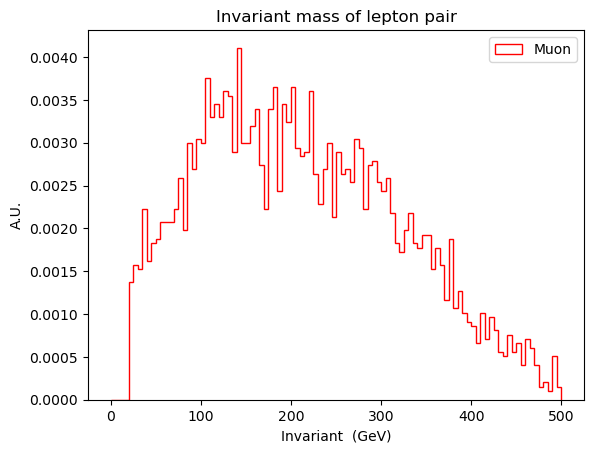

In [38]:
is_electron = (abs(gen.id) == 11) & (gen.status == 1)
is_muon = (abs(gen.id) == 13) & (gen.status == 1)
gen_electrons = gen[is_electron]
gen_muons = gen[is_muon]

correct_electron_pair = ak.sum(gen_electrons.id, axis=1) == 0
correct_muon_pair = ak.sum(gen_muons.id, axis=1) == 0

id_mask = (is_electron | is_muon) & (gen.pt > 20)
event_mask = (ak.num(gen_electrons) == 2) & (ak.num(gen_muons) == 2) & correct_electron_pair & correct_muon_pair & id_mask

gen_p4=gen[event_mask]


plt.hist(ak.flatten(gen_p4.pt), bins=100, range=(0, 500), color='red', label = "Muon", histtype='step',density=True)


plt.xlabel('Invariant  (GeV)')
plt.ylabel('A.U.')
plt.title('Invariant mass of lepton pair')
plt.legend(loc = 'upper right')